In [10]:
import time
import numpy as np
import matplotlib.pyplot as plt

from qiskit import transpile
from qiskit import QuantumCircuit, ClassicalRegister, QuantumRegister
from qiskit.circuit import Parameter
from qiskit.circuit.library import EfficientSU2
from qiskit_aer import Aer
from qiskit_aer.primitives import Sampler, EstimatorV2
from qiskit_algorithms.minimum_eigensolvers import NumPyMinimumEigensolver, VQE
from qiskit_algorithms.optimizers import SLSQP, COBYLA
from qiskit_nature.second_q.transformers import FreezeCoreTransformer
from qiskit_nature.second_q.formats.molecule_info import MoleculeInfo
from qiskit_nature.second_q.mappers import ParityMapper
from qiskit_nature.second_q.circuit.library import UCCSD, HartreeFock
from qiskit_nature.second_q.drivers import PySCFDriver

In [11]:
np.random.seed(999999)
p0 = np.random.random()
target_distr = {0: p0, 1: 1 - p0}

In [12]:
params = [Parameter("theta"), Parameter("phi"), Parameter("lam")]

def get_var_form(params):
    qr = QuantumRegister(1, name="q")
    cr = ClassicalRegister(1, name="c")
    qc = QuantumCircuit(qr, cr)
    qc.u(params[0], params[1], params[2], qr[0])
    qc.measure(qr, cr[0])
    return qc

qc = get_var_form(params)

In [13]:
sampler = Sampler()

def objective_function(params):
    """Compares the output distribution of our circuit with
    parameters `params` to the target distribution."""
    # Simulate the circuit instance with paramters
    result = sampler.run(circuits=qc, parameter_values=params).result()
    # Get the quasi distribution for each measured state
    output_distr = result.quasi_dists[0]
    # Calculate the cost as the distance between the output
    # distribution and the target distribution
    cost = sum(
        abs(target_distr.get(i, 0) - output_distr.get(i, 0))
        for i in range(2**qc.num_qubits)
    )
    return cost

In [14]:
optimizer = COBYLA(maxiter=500, tol=0.0001)
# Create the initial parameters (noting that our
# single qubit variational form has 3 parameters)
initial_point = np.random.rand(3)

result = optimizer.minimize(fun=objective_function, x0=initial_point)

# Obtain the output distribution using the final parameters
output_distr = (
    sampler.run(circuits=qc, parameter_values=result.x)
    .result()
    .quasi_dists[0]
)

print("Parameters Found:", result.x)
print("Target Distribution:", target_distr)
print("Obtained Distribution:", output_distr)
print("Cost:", objective_function(result.x))

Parameters Found: [2.01704738 1.77681145 1.98491612]
Target Distribution: {0: 0.308979188922057, 1: 0.691020811077943}
Obtained Distribution: {0: 0.3115234375, 1: 0.6884765625}
Cost: 0.003135372155885996


# I don't know what this is for, i commented it out and it still works

In [15]:
# entanglements = ["linear", "full"]
# for entanglement in entanglements:
#     form = EfficientSU2(num_qubits=4, entanglement=entanglement)
#     print(f"{entanglement} entanglement:")
#     # We initialize all parameters to 0 for this demonstration
#     display(form.decompose().draw("mpl", fold=-1))

In [16]:
def get_qubit_op(dist):
    # Define Molecule
    molecule = MoleculeInfo(
        # Coordinates in Angstrom
        symbols=["H", "H"],
        coords=([0.0, 0.0, 0.0], [dist, 0.0, 0.0]),
        multiplicity=1,  # = 2S + 1
        charge=0,
    )

    driver = PySCFDriver.from_molecule(molecule)

    properties = driver.run()

    # Now you can get the reduced electronic structure problem
    problem = FreezeCoreTransformer(
        freeze_core=True, remove_orbitals=[-3, -2]
    ).transform(properties)

    num_particles = problem.num_particles
    num_spatial_orbitals = problem.num_spatial_orbitals

    mapper = ParityMapper(num_particles=num_particles)
    qubit_op = mapper.map(problem.second_q_ops()[0])
    return qubit_op, num_particles, num_spatial_orbitals, problem, mapper

In [17]:
def exact_solver(qubit_op, problem):
    sol = NumPyMinimumEigensolver().compute_minimum_eigenvalue(qubit_op)
    result = problem.interpret(sol)
    return result

start_time = time.time()
distances = np.arange(0.4, 1.5, 0.05)
exact_energies = []
vqe_energies = []
optimizer = SLSQP(maxiter=10)

noiseless_estimator = EstimatorV2()

# list to store per-iteration VQE energies for each distance
vqe_convergence_all = []

for dist in distances:
    (qubit_op, num_particles, num_spatial_orbitals, problem, mapper) = get_qubit_op(
        dist
)

    result = exact_solver(qubit_op, problem)
    exact_energies.append(result.total_energies[0].real)
    init_state = HartreeFock(num_spatial_orbitals, num_particles, mapper)
    
    var_form = UCCSD(
        num_spatial_orbitals, num_particles, mapper, initial_state=init_state
)
    backend = Aer.get_backend('aer_simulator_statevector')
    var_form = transpile(var_form, backend)

    vqe = VQE(
        noiseless_estimator,
        var_form,
        optimizer,
        initial_point=[0] * var_form.num_parameters,
    )
 
    
    vqe_calc = vqe.compute_minimum_eigenvalue(qubit_op)
    vqe_result = problem.interpret(vqe_calc).total_energies[0].real
    vqe_energies.append(vqe_result)
    print(
        f"Interatomic Distance: {np.round(dist, 2)}",
        f"VQE Result: {vqe_result:.5f}",
        f"Exact Energy: {exact_energies[-1]:.5f}",
    )

print("All energies have been calculated")
end_time = time.time()
execution_time1 = end_time - start_time
print(f"Execution time: {execution_time1} seconds")

Interatomic Distance: 0.4 VQE Result: -0.91415 Exact Energy: -0.91415
Interatomic Distance: 0.45 VQE Result: -0.99842 Exact Energy: -0.99842
Interatomic Distance: 0.5 VQE Result: -1.05516 Exact Energy: -1.05516
Interatomic Distance: 0.55 VQE Result: -1.09263 Exact Energy: -1.09263
Interatomic Distance: 0.6 VQE Result: -1.11629 Exact Energy: -1.11629
Interatomic Distance: 0.65 VQE Result: -1.12990 Exact Energy: -1.12990
Interatomic Distance: 0.7 VQE Result: -1.13619 Exact Energy: -1.13619
Interatomic Distance: 0.75 VQE Result: -1.13712 Exact Energy: -1.13712
Interatomic Distance: 0.8 VQE Result: -1.13415 Exact Energy: -1.13415
Interatomic Distance: 0.85 VQE Result: -1.12836 Exact Energy: -1.12836
Interatomic Distance: 0.9 VQE Result: -1.12056 Exact Energy: -1.12056
Interatomic Distance: 0.95 VQE Result: -1.11134 Exact Energy: -1.11134
Interatomic Distance: 1.0 VQE Result: -1.10115 Exact Energy: -1.10115
Interatomic Distance: 1.05 VQE Result: -1.09034 Exact Energy: -1.09034
Interatomic D

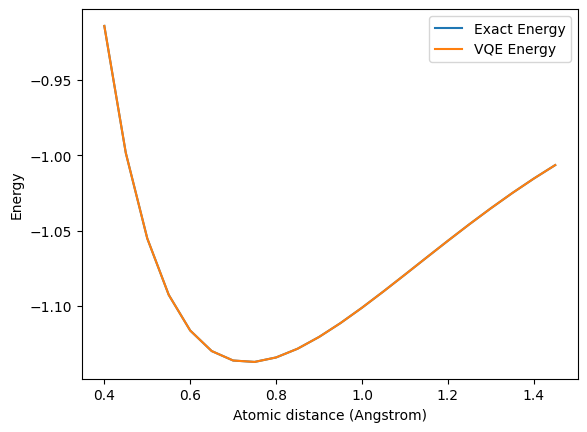

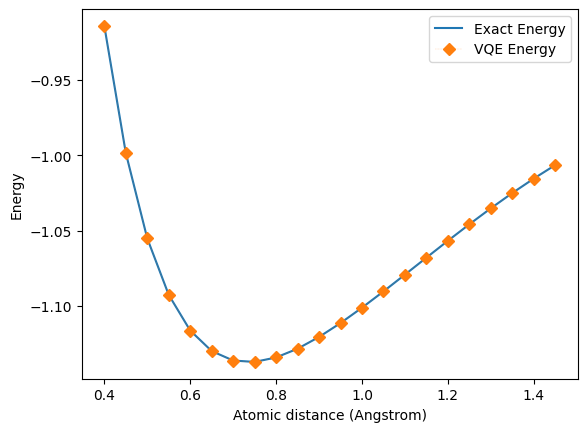

<Figure size 640x480 with 0 Axes>

In [ ]:

plt.plot(distances, exact_energies, label="Exact Energy")
plt.plot(distances, vqe_energies, label="VQE Energy")
plt.xlabel("Atomic distance (Angstrom)")
plt.ylabel("Energy")
plt.legend()
plt.show()

plt.plot(distances, exact_energies, label="Exact Energy", ls='-', linewidth=1.5)
plt.plot(distances, vqe_energies, label="VQE Energy", ls=':', marker='D', linewidth=0.2)
plt.xlabel("Atomic distance (Angstrom)")
plt.ylabel("Energy")
plt.legend()
plt.show()